# Pre/post state analysis

Paired pre- vs post-training activity at each `(cell, room, cycle)` visit, labelled as **AA**, **AD**, **DA**, or **DD** (active/dead in pre vs post). A phase is **active** when `signal_max >= dead_threshold`; optional `r2` gating is controlled by `R2_MIN_SELECTION` and `R2_SELECTION_POLICY` (`"pre"`, `"post"`, or `"pre-post"`).

**Part 1** — state distributions, DD proportions, DA activations, ever-DA pair dynamics, timelines, Gaussian-sum maps, and perfect DD→DA→AA pairs (1e–1i).

Computations in `analysis.pre_post_cells_analysis`; plotting in `analysis.pf_evolution_plots`.
Computations in `analysis.pre_post_cells_analysis`; plotting in `analysis.pf_evolution_plots`.


In [12]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        for _p in (str(_path), str(_path / "src")):
            if _p not in sys.path:
                sys.path.insert(0, _p)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.gaussian_fit_cycle_analysis import build_cell_receptive_fields_df
from analysis import dead_cells_analysis as dead
from analysis import pre_post_cells_analysis as pre_post
from analysis import pf_evolution_plots as pfp
from analysis.pf_evolution_plots import save_figure
from cycles.cycles_paths import CYCLES_PLOTS_BASE, CYCLES_RESULTS_BASE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Notebook-wide constants


In [13]:
# --- Input ---
CONFIG = "200s_8_100"
RESULTS_DIR = CYCLES_RESULTS_BASE / CONFIG
GAUSSIANS_RESULTS_PATH = RESULTS_DIR / "gaussian_rf_fits.npz"
GAUSSIANS_PRE_RESULTS_PATH = RESULTS_DIR / "gaussian_rf_fits_pre.npz"
assert GAUSSIANS_RESULTS_PATH.is_file(), (
    f"Missing {GAUSSIANS_RESULTS_PATH.resolve()}"
)
assert GAUSSIANS_PRE_RESULTS_PATH.is_file(), (
    f"Missing {GAUSSIANS_PRE_RESULTS_PATH.resolve()} "
    "(run `estimate-gaussians-rf --input <cycles_ratemaps_pre.npz>`)"
)

# --- Output (figures are saved here as PDF) ---
OUTPUT_DIR = CYCLES_PLOTS_BASE / "pre_post_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Dead-cell thresholds (on signal_max) ---
DEAD_THRESHOLD = 0.1
DEAD_THRESHOLDS = (0.1, 0.15, 0.2, 0.25, 0.3, 0.5)

# --- Gaussian fit quality gate; None = signal_max only ---
R2_MIN_SELECTION = 0.6 # None
R2_SELECTION_POLICY = "post"  # "pre" | "post" | "pre-post"

ACTIVE_CRITERION_LABEL = pre_post.active_criterion_label(
    dead_threshold=DEAD_THRESHOLD,
    r2_min_selection=R2_MIN_SELECTION,
    r2_selection_policy=R2_SELECTION_POLICY,
)

# --- Gaussian-sum render resolution ---
RENDER_SHAPE = (40, 40)

with np.load(GAUSSIANS_RESULTS_PATH) as _meta:
    N_GAUSSIANS = int(_meta["n_gaussians"])
print(f"n_gaussians = {N_GAUSSIANS}")


def finalize(fig, name):
    """Show *fig* inline and save it as a PDF under OUTPUT_DIR."""
    out_path = OUTPUT_DIR / f"{name}.pdf"
    save_figure(fig, out_path, close=False)
    plt.show()
    plt.close(fig)
    print(f"saved {out_path}")

n_gaussians = 2


In [14]:
df_rf_pre = build_cell_receptive_fields_df(GAUSSIANS_PRE_RESULTS_PATH)
df_rf = build_cell_receptive_fields_df(GAUSSIANS_RESULTS_PATH)

CYCLES, ROOMS = dead.infer_grid_shape(df_rf)
N_CYCLES, N_ROOMS = len(CYCLES), len(ROOMS)
N_CELLS = int(df_rf.index.get_level_values("cell_idx").nunique())
print(
    f"{N_CELLS} cells x {N_CYCLES} cycles x {N_ROOMS} rooms "
    f"(rooms {ROOMS[0]}..{ROOMS[-1]}, cycles {CYCLES[0]}..{CYCLES[-1]})"
)

state_df = pre_post.pre_post_state_df(
    df_rf_pre,
    df_rf,
    dead_threshold=DEAD_THRESHOLD,
    r2_min_selection=R2_MIN_SELECTION,
    r2_selection_policy=R2_SELECTION_POLICY,
)
state_df.head()

1000 cells x 10 cycles x 20 rooms (rooms 1..20, cycles 0..9)


,visit_idx,cell_idx,cycle_id,room_id,signal_max_pre,signal_max_post,r2_pre,r2_post,active_pre,active_post,state
0,0,0,0,11,2.679608,0.003923,0.491978,0.000241,True,False,AD
1,0,1,0,11,2.217581,0.000654,0.704558,0.000511,True,False,AD
2,0,2,0,11,0.006624,1.244221,0.000272,0.981062,False,True,DA
3,0,3,0,11,1.630309,0.908912,0.822692,0.941431,True,True,AA
4,0,4,0,11,0.077046,0.000000,0.455017,NaN,False,False,DD


## 1. Pre/post state distributions

At each visit, label the cell-room pair as **AA** (both active), **AD** (active pre, dead post), **DA** (dead pre, active post), or **DD** (both dead). A phase is active when `signal_max >= dead_threshold`; `r2 > R2_MIN_SELECTION` applies per `R2_SELECTION_POLICY` when that threshold is not `None`.

### 1a — State table summary


In [15]:
print(f"{len(state_df):,} (cell, cycle, room) visits")
print("\nGlobal state counts:")
print(state_df["state"].value_counts().sort_index().to_string())

state_by_cycle = (
    state_df.groupby(["cycle_id", "state"], sort=True)
    .size()
    .unstack(fill_value=0)
)
print("\nPer-cycle state counts:")
print(state_by_cycle.to_string())

200,000 (cell, cycle, room) visits

Global state counts:
state
AA     28710
AD      6833
DA       761
DD    163696

Per-cycle state counts:
state       AA    AD   DA     DD
cycle_id                        
0         3150  1436  197  15217
1         2656   707  103  16534
2         2781   567   87  16565
3         2830   613   87  16470
4         2874   531   77  16518
5         2851   578   71  16500
6         2863   564   51  16522
7         2910   580   37  16473
8         2913   609   28  16450
9         2882   648   23  16447


### 1b — Stacked state bars per room and cycle


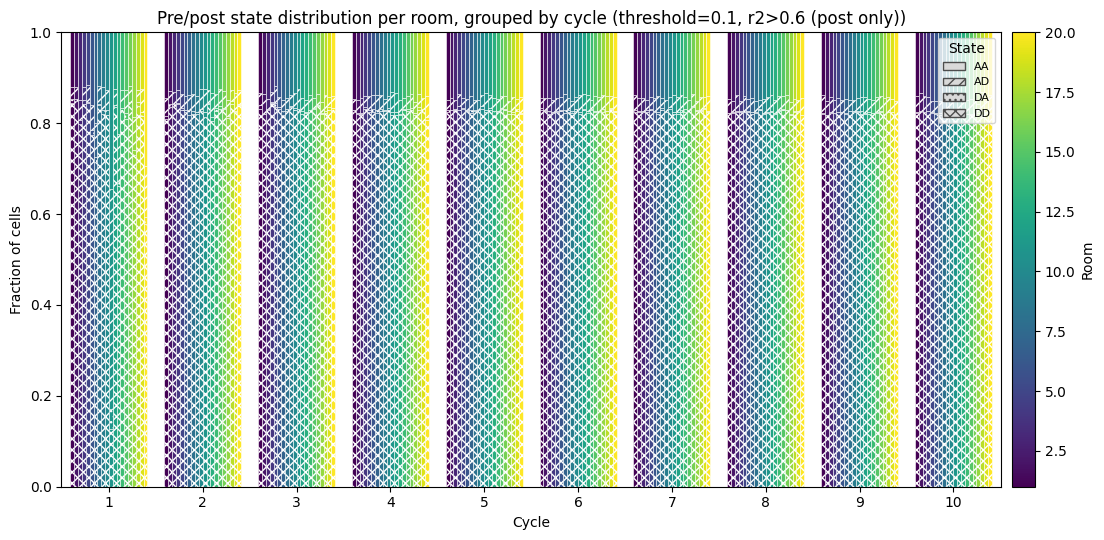

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1b_state_stacked_bars.pdf


In [16]:
state_prop = pre_post.state_proportion_by_room_cycle(state_df)
fig = pfp.plot_pre_post_state_stacked_bars(
    state_prop,
    title=(
        "Pre/post state distribution per room, grouped by cycle "
        f"({ACTIVE_CRITERION_LABEL})"
    ),
)
finalize(fig, "1b_state_stacked_bars")

### 1c — DD proportion vs dead threshold


DD proportions / threshold:   0%|          | 0/6 [00:00<?, ?it/s]

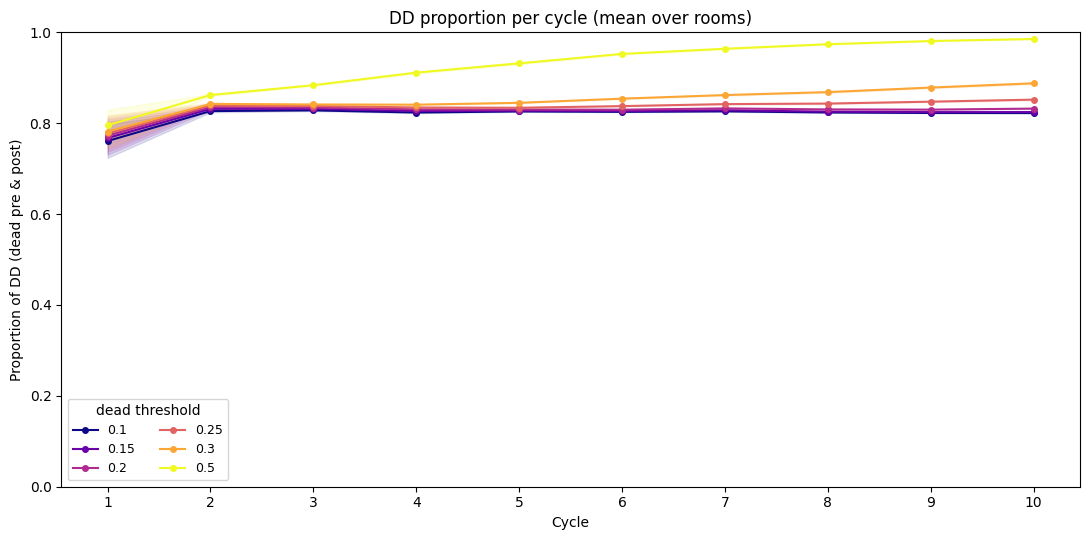

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1c_dd_proportion_multithreshold.pdf


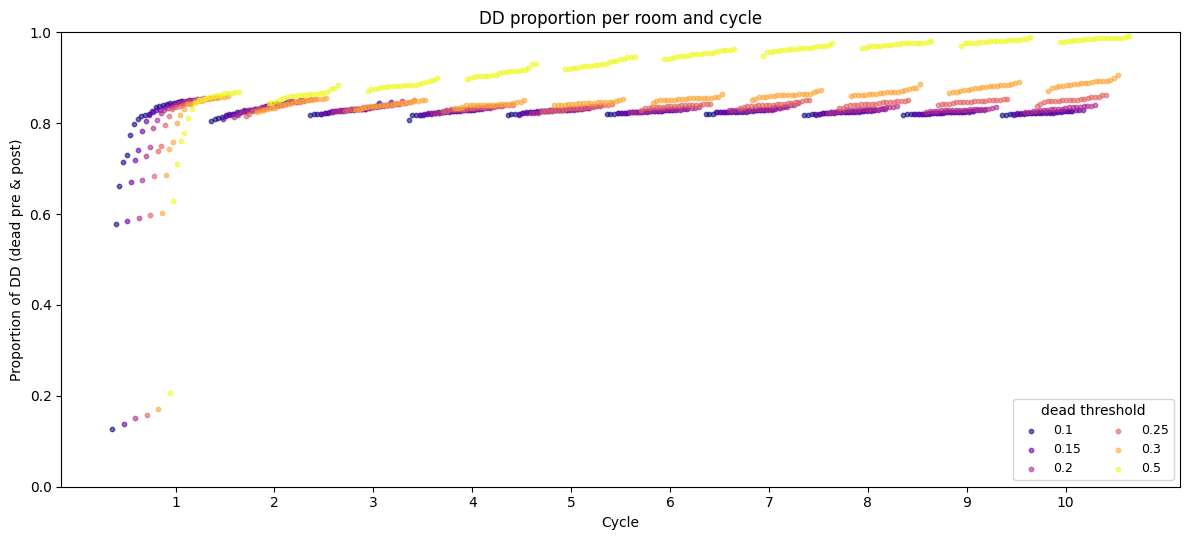

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1c_dd_proportion_multithreshold_scatter.pdf


In [17]:
dd_prop_multi = pre_post.dd_proportion_multi_threshold(
    df_rf_pre,
    df_rf,
    thresholds=DEAD_THRESHOLDS,
    r2_min_selection=R2_MIN_SELECTION,
    r2_selection_policy=R2_SELECTION_POLICY,
)
fig = pfp.plot_dd_proportion_multithreshold_lines(dd_prop_multi)
finalize(fig, "1c_dd_proportion_multithreshold")

fig = pfp.plot_dd_proportion_multithreshold_scatter(dd_prop_multi)
finalize(fig, "1c_dd_proportion_multithreshold_scatter")

### 1d — DA activations per cell vs threshold

A **DA activation** is a visit where the cell is dead pre and active post (analogous to recoveries in the dead-cell analysis).

DA activations / threshold:   0%|          | 0/6 [00:00<?, ?it/s]

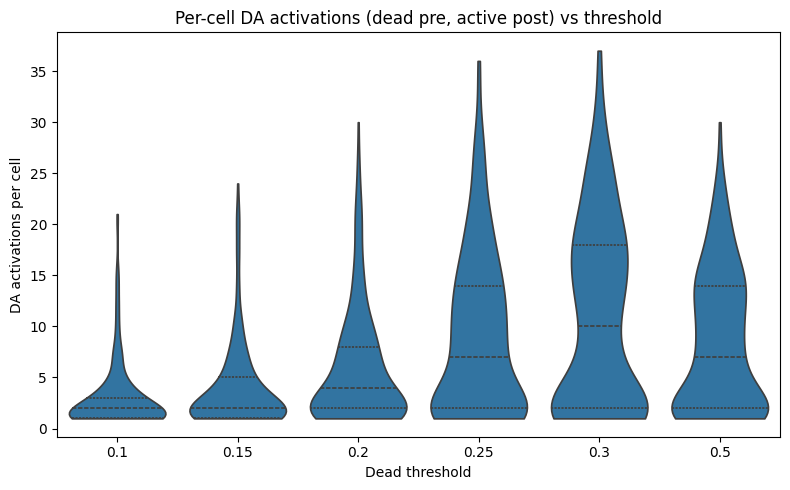

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1d_da_activations_violin.pdf


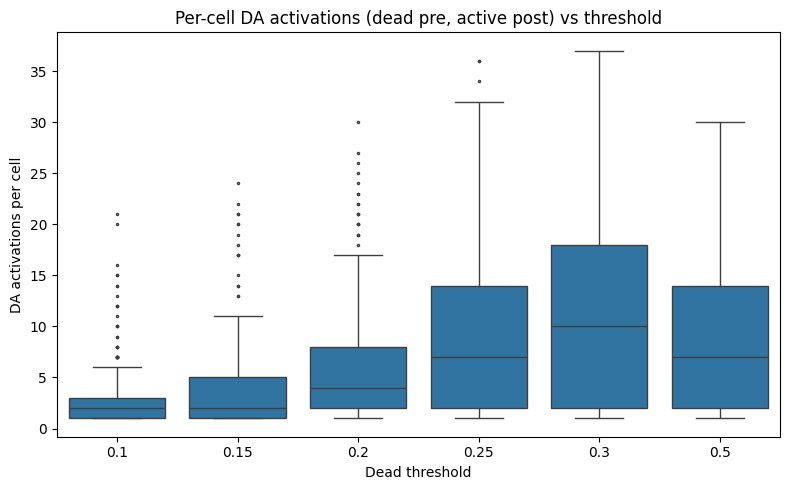

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1d_da_activations_boxplot.pdf


In [18]:
da_multi = pre_post.da_activations_multi_threshold(
    df_rf_pre,
    df_rf,
    thresholds=DEAD_THRESHOLDS,
    r2_min_selection=R2_MIN_SELECTION,
    r2_selection_policy=R2_SELECTION_POLICY,
)
fig = pfp.plot_da_activations_violin(da_multi)
finalize(fig, "1d_da_activations_violin")

fig = pfp.plot_da_activations_boxplot(da_multi)
finalize(fig, "1d_da_activations_boxplot")

### 1e — Pre-first-DA AA/AD pair counts vs threshold

Among `(cell, room)` pairs with at least one DA visit: at each cycle, count pairs still **before** their first DA cycle whose state is AA or AD. One line per dead threshold.

pre-DA AA/AD counts / threshold:   0%|          | 0/6 [00:00<?, ?it/s]

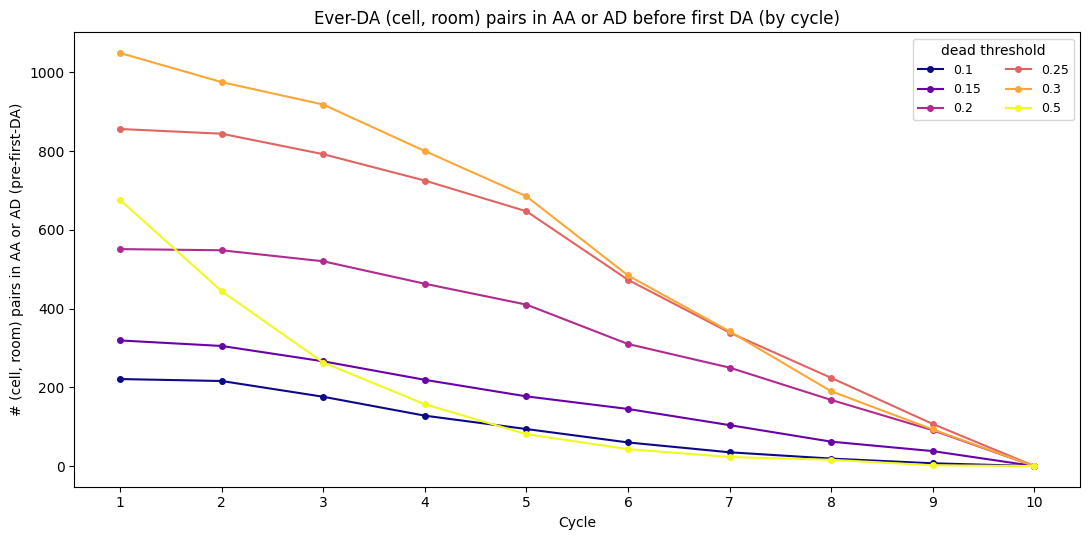

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1e_pre_da_aa_ad_count_multithreshold.pdf


In [19]:
pre_da_counts_multi = pre_post.pre_da_aa_ad_count_multi_threshold(
    df_rf_pre,
    df_rf,
    thresholds=DEAD_THRESHOLDS,
    r2_min_selection=R2_MIN_SELECTION,
    r2_selection_policy=R2_SELECTION_POLICY,
)
fig = pfp.plot_pre_da_aa_ad_count_multithreshold_lines(pre_da_counts_multi)
finalize(fig, "1e_pre_da_aa_ad_count_multithreshold")



### 1f — State counts per cycle (ever-DA pairs only)

Stacked bars of AA/AD/DA/DD **counts** across `(cell, room)` pairs that were DA at least once.

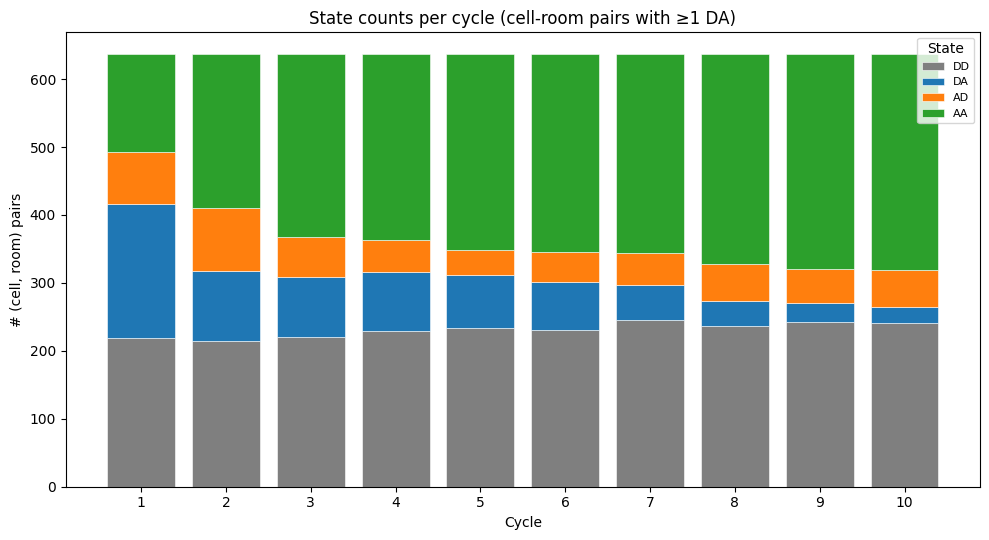

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1f_ever_da_state_count_stacked_bars.pdf


In [20]:
ever_da_counts = pre_post.ever_da_state_counts_by_cycle(state_df)
fig = pfp.plot_ever_da_state_count_stacked_bars(ever_da_counts)
finalize(fig, "1f_ever_da_state_count_stacked_bars")



### 1g — State timelines for selected pairs

First three ever-DA `(cell, room)` pairs (by index) with a non-AA state after first DA, plus one pair that stays AA-only after first DA.

Selected 4 pairs for timelines:
 cell_idx  room_id  first_da_cycle
        1        1               4
        1        6               3
        1        7               0
        1       17               6


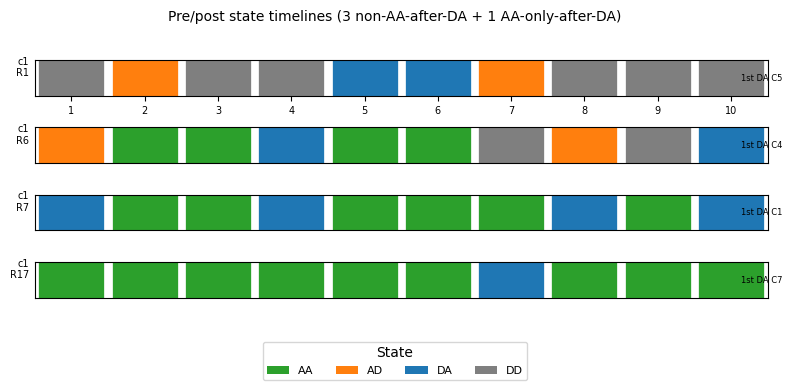

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1g_state_timelines.pdf


In [21]:
timeline_pairs = pre_post.select_timeline_pairs(state_df, n_violators=3)
print(f"Selected {len(timeline_pairs)} pairs for timelines:")
print(timeline_pairs.to_string(index=False))

fig = pfp.plot_pre_post_state_timeline(
    state_df,
    timeline_pairs,
    CYCLES,
    title="Pre/post state timelines (3 non-AA-after-DA + 1 AA-only-after-DA)",
)
finalize(fig, "1g_state_timelines")



### 1h — Gaussian-sum pre/post maps for selected pairs

Pre | post Gaussian-sum fields across all cycles for each pair selected in §1g.

/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


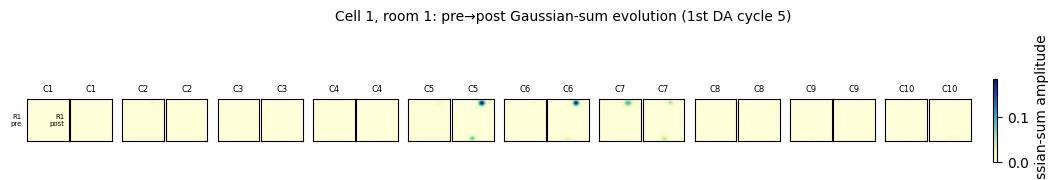

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1h_cell1_room1_gaussian_evolution.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


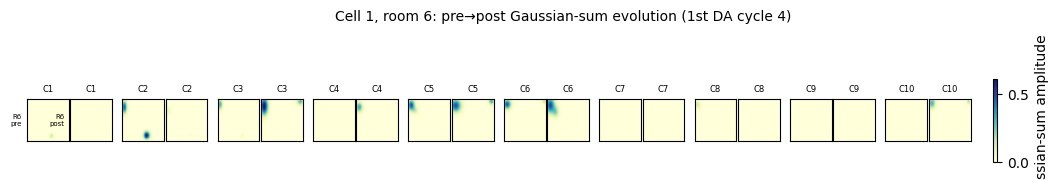

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1h_cell1_room6_gaussian_evolution.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


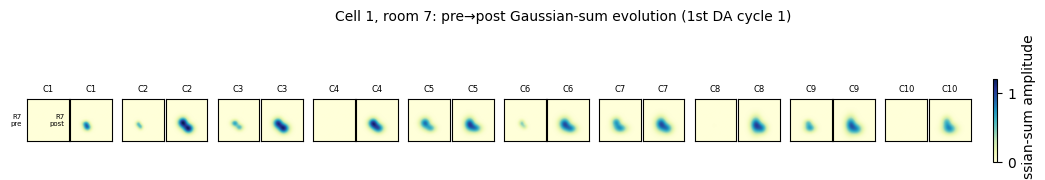

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1h_cell1_room7_gaussian_evolution.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


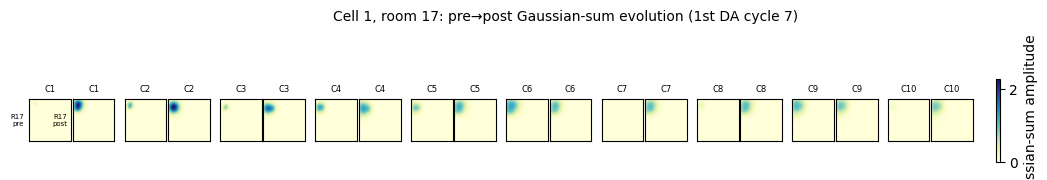

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1h_cell1_room17_gaussian_evolution.pdf


In [22]:
for _, pair in timeline_pairs.iterrows():
    cell_idx = int(pair["cell_idx"])
    room_id = int(pair["room_id"])
    first_da = int(pair["first_da_cycle"])
    fig = pfp.plot_pre_post_cell_room_cycle_evolution(
        cell_idx,
        df_rf_pre,
        df_rf,
        cycles=CYCLES,
        rooms=[room_id],
        n_gaussians=N_GAUSSIANS,
        render_shape=RENDER_SHAPE,
        title=(
            f"Cell {cell_idx}, room {room_id}: pre→post Gaussian-sum evolution "
            f"(1st DA cycle {first_da + 1})"
        ),
    )
    finalize(fig, f"1h_cell{cell_idx}_room{room_id}_gaussian_evolution")



### 1i — Perfect DD→DA→AA pairs

A **perfect** `(cell, room)` is DD at every cycle before its first DA, DA at that activation cycle, and AA at every cycle after. One line per dead threshold shows how many perfect pairs activate at each cycle. Below: timelines and Gaussian-sum maps for four examples.

perfect DA activations / threshold:   0%|          | 0/6 [00:00<?, ?it/s]

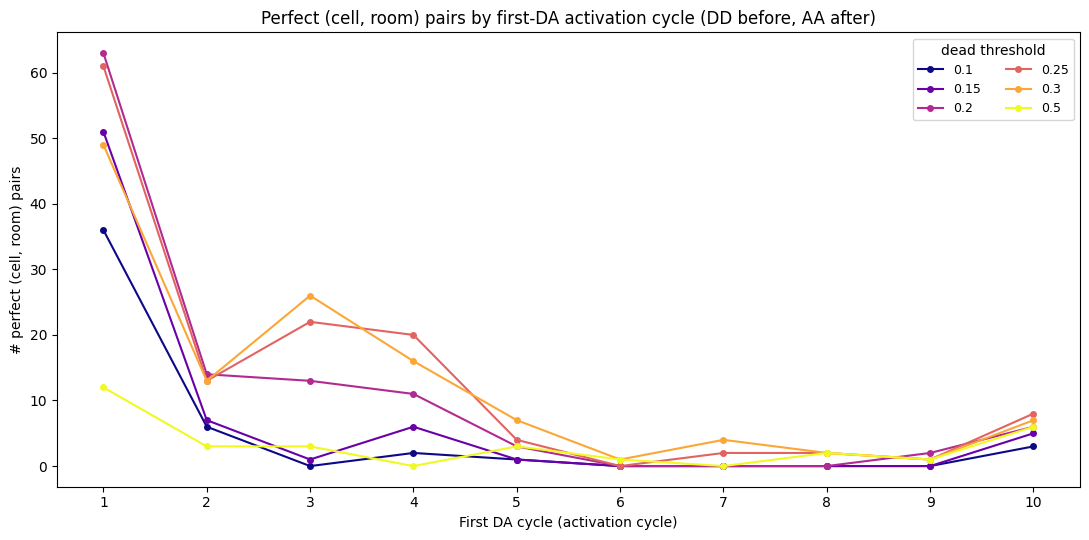

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_da_activation_multithreshold.pdf


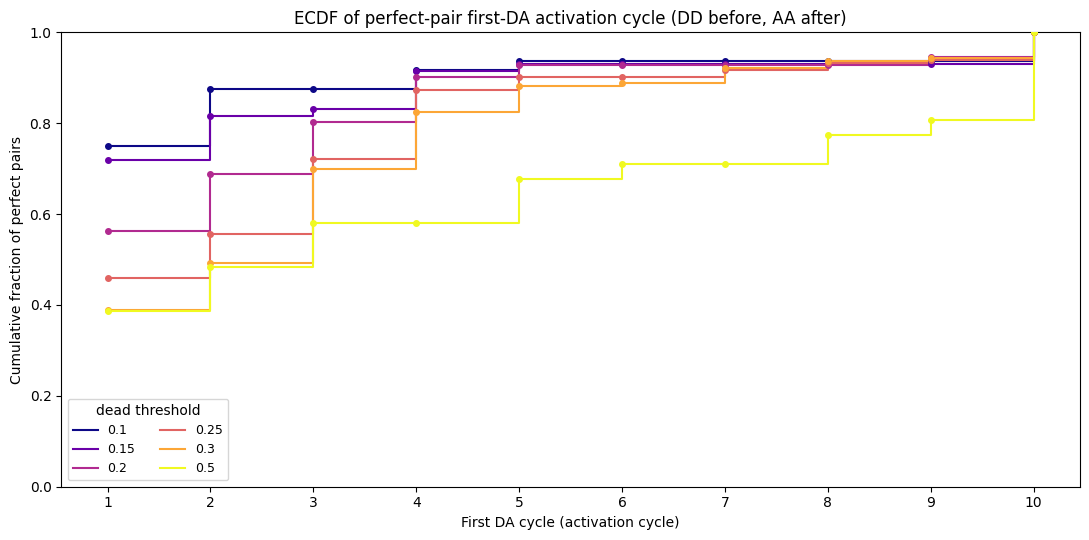

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_da_activation_multithreshold_ecdf.pdf
48 perfect pairs at primary threshold
Showing 4 examples:
 cell_idx  room_id  first_da_cycle
        2       11               0
        9       11               1
       20       10               0
       25       11               0


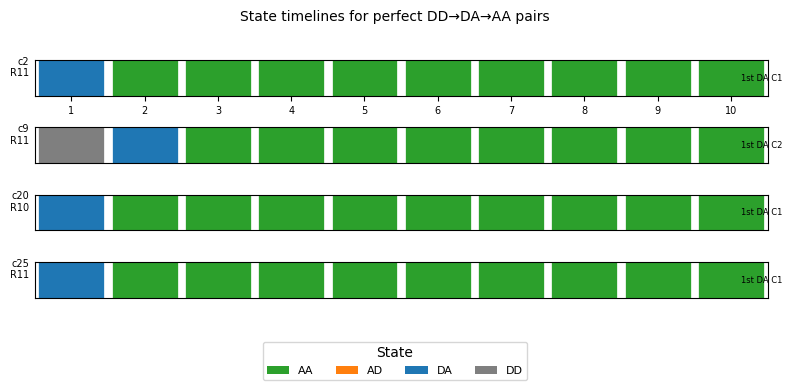

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_state_timelines.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


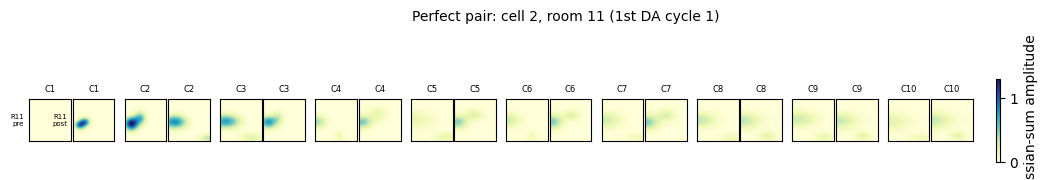

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_cell2_room11_gaussian_evolution.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


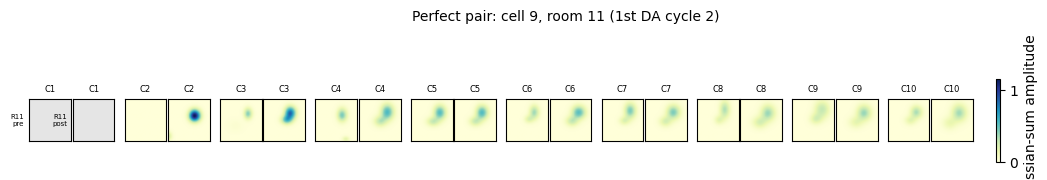

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_cell9_room11_gaussian_evolution.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


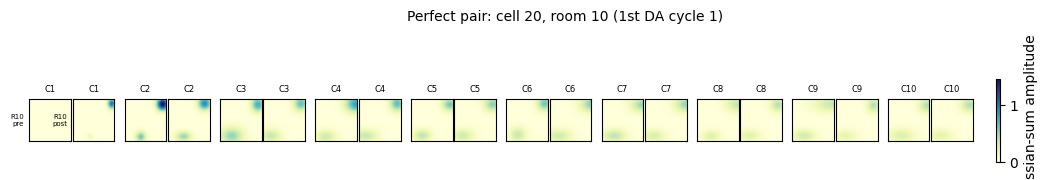

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_cell20_room10_gaussian_evolution.pdf


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/src/analysis/pf_evolution_plots.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


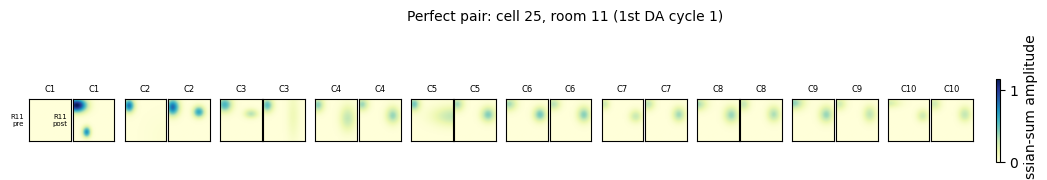

saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/plots/cycles/pre_post_analysis/1i_perfect_cell25_room11_gaussian_evolution.pdf


In [24]:
perfect_counts_multi = pre_post.perfect_da_activation_count_multi_threshold(
    df_rf_pre,
    df_rf,
    thresholds=DEAD_THRESHOLDS,
    r2_min_selection=R2_MIN_SELECTION,
    r2_selection_policy=R2_SELECTION_POLICY,
)
fig = pfp.plot_perfect_da_activation_count_multithreshold_lines(
    perfect_counts_multi
)
finalize(fig, "1i_perfect_da_activation_multithreshold")

fig = pfp.plot_perfect_da_activation_count_multithreshold_ecdf(
    perfect_counts_multi
)
finalize(fig, "1i_perfect_da_activation_multithreshold_ecdf")

perfect_pairs = pre_post.select_perfect_pairs(state_df, n=4)
print(f"{len(pre_post.perfect_cell_rooms_df(state_df)):,} perfect pairs at primary threshold")
print(f"Showing {len(perfect_pairs)} examples:")
print(perfect_pairs.to_string(index=False))

fig = pfp.plot_pre_post_state_timeline(
    state_df,
    perfect_pairs,
    CYCLES,
    title="State timelines for perfect DD→DA→AA pairs",
)
finalize(fig, "1i_perfect_state_timelines")

for _, pair in perfect_pairs.iterrows():
    cell_idx = int(pair["cell_idx"])
    room_id = int(pair["room_id"])
    first_da = int(pair["first_da_cycle"])
    fig = pfp.plot_pre_post_cell_room_cycle_evolution(
        cell_idx,
        df_rf_pre,
        df_rf,
        cycles=CYCLES,
        rooms=[room_id],
        n_gaussians=N_GAUSSIANS,
        render_shape=RENDER_SHAPE,
        title=(
            f"Perfect pair: cell {cell_idx}, room {room_id} "
            f"(1st DA cycle {first_da + 1})"
        ),
    )
    finalize(fig, f"1i_perfect_cell{cell_idx}_room{room_id}_gaussian_evolution")
